In [39]:
import pandas as pd
df = pd.read_csv("C:/Users/Ujjal Mondal/Downloads/WA_Fn-UseC_-Telco-Customer-Churn (1).csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [40]:
df.shape

(7043, 21)

In [41]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [44]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [45]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [46]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [47]:
df = df.dropna()

In [48]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [49]:
df['Churn'].value_counts(normalize = True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

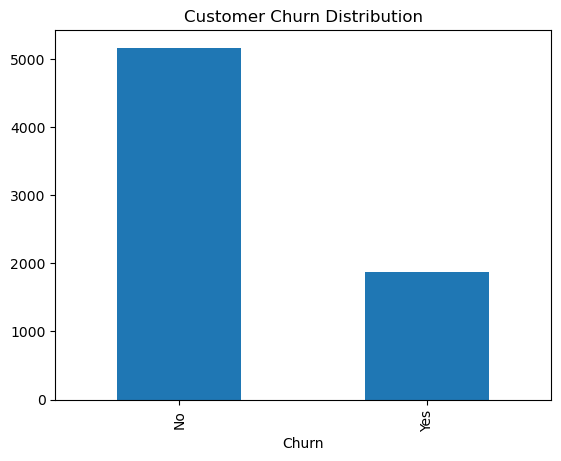

In [50]:
import matplotlib.pyplot as plt
df['Churn'].value_counts().plot(kind = 'bar')
plt.title("Customer Churn Distribution")
plt.show()

In [57]:
import re

df.columns = [
    re.sub(r'([a-z0-9])(A-Z)',r'\1_\2',col).lower()
    for col in df.columns
]

df.columns = df.columns.str.replace('i_d','id')

In [58]:
print(df.columns)

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_t_v', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')


### EDA 

In [59]:
pd.crosstab(df['gender'],df['churn'])

churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


In [60]:
pd.crosstab(df['gender'],df['churn'],normalize = 'index') * 100

churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


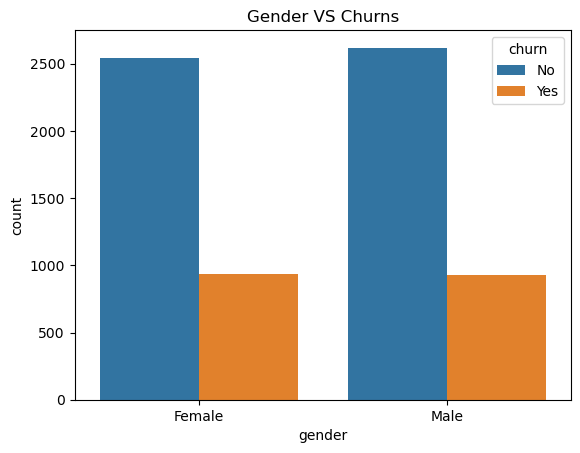

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x ='gender', hue = 'churn', data = df)
plt.title('Gender VS Churns')
plt.show()

### Contract type vs Churn 

In [63]:
pd.crosstab(df['contract'],df['churn'],normalize = 'index')*100

churn,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


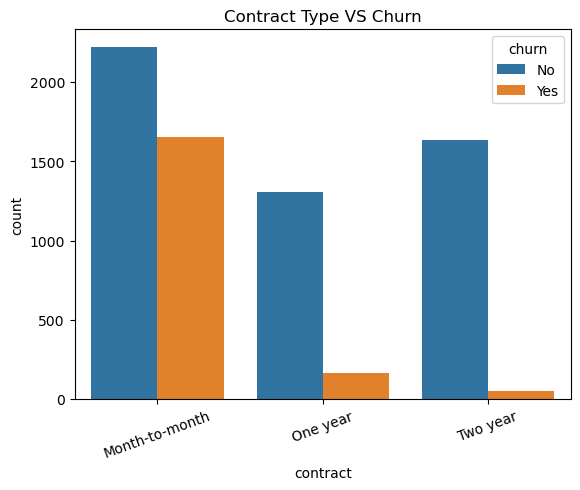

In [65]:
sns.countplot(x = 'contract', hue = 'churn', data = df)
plt.xticks(rotation = 20)
plt.title('Contract Type VS Churn')
plt.show()

###  Payment Method VS Churn

In [66]:
pd.crosstab(df['payment_method'],df['churn'],normalize = 'index')* 100

churn,No,Yes
payment_method,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


### Monthly Charges Analysis

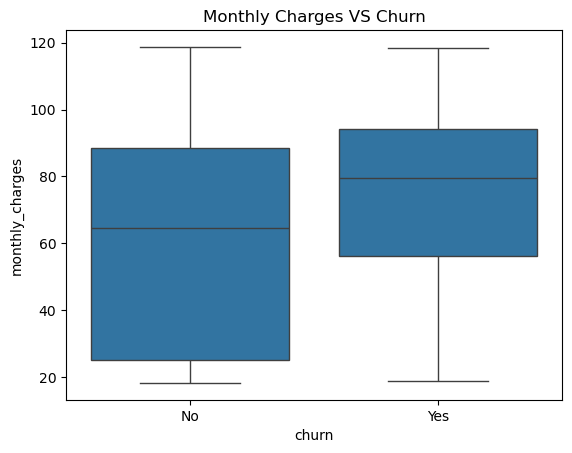

In [68]:
sns.boxplot(x = 'churn', y = 'monthly_charges', data = df)
plt.title('Monthly Charges VS Churn')
plt.show()

### Tenure VS Churn

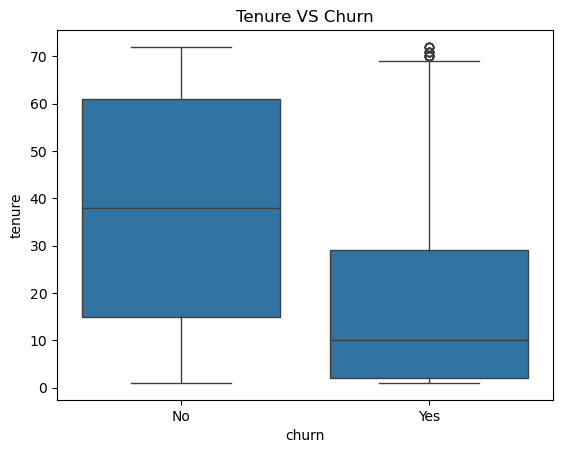

In [69]:
sns.boxplot(x = 'churn', y = 'tenure', data = df)
plt.title('Tenure VS Churn')
plt.show()

### Senior Citizen Mapping

In [71]:
df['senior_citizen'] = df['senior_citizen'].map({0:'No', 1:'Yes'})

In [72]:
df['senior_citizen'].value_counts()

senior_citizen
No     5890
Yes    1142
Name: count, dtype: int64

### Tenure Groups

In [77]:
def tenure_group(tenure):
    if tenure <= 12:
        return '0-1 Year'
    elif tenure <= 24:
        return '1-2 Years'
    elif tenure <= 48:
        return '2-4 Years'
    else:
        return'4+ Years'

df['tenure_group'] = df['tenure'].apply(tenure_group)
    

In [78]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_t_v,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,tenure_group
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 Year
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4 Years
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 Year
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 Years
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 Year


### Analyze Tenure Group VS Churn

In [79]:
pd.crosstab(['tenure_group'], df['churn'],normalize = 'index')*100

churn,No,Yes
row_0,,
tenure_group,73.421502,26.578498


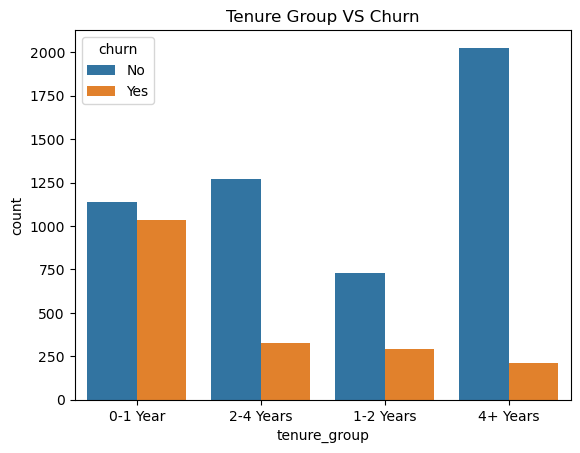

In [80]:
sns.countplot(x = 'tenure_group', hue = 'churn', data = df)
plt.title('Tenure Group VS Churn')
plt.show()

### Revenue Analysis

In [81]:
df['monthly_charges'].sum()

np.float64(455661.0)

### Revenue Lost Due To Churn

In [82]:
churn_revenue = df[df['churn'] == 'Yes']['monthly_charges'].sum()
print (churn_revenue)

139130.85


### High Risk Customers

In [83]:
high_risk = df[
    (df['contract'] == ' Month-to-Month') &
    (df['monthly_charges'] > 70) &
    (df['tenure'] < 12)
]
high_risk.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_t_v,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,tenure_group


# Business Insights Write 

#### Month to month customers have hights churn.
#### Customers with higher monthly charges  are more likely to churn.
#### Customers with short tenure show higher churn probablity.
#### Electronic check payment users curn more frequently.

In [86]:
from sqlalchemy import create_engine

# step 1: conncet to postgreSQL
# Replace placeholders with your actual details
username = "postgres"      #default user
password = "767977" 
host  = "localhost"
port = "5432"
database = "telecome_churn"

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

#step 2 : load data frame into postgreSQL
table_name = 'customer_churn'
df.to_sql(table_name, engine, if_exists = "replace", index=False)

print(f"Data succesddfully loaded into table '{table_name}' in database '{database}'.")

Data succesddfully loaded into table 'customer_churn' in database 'telecome_churn'.
